In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
#Cargar CSV desde el PC
from google.colab import files
uploaded = files.upload()

Saving UberDataset.csv to UberDataset (3).csv


In [34]:
data = pd.read_csv('UberDataset.csv')
data

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,"Friday, January 1, 2016","Friday, January 1, 2016",Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,"Saturday, January 2, 2016","Saturday, January 2, 2016",Business,Fort Pierce,Fort Pierce,5.0,NaN
2,"Saturday, January 2, 2016","Saturday, January 2, 2016",Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,"Tuesday, January 5, 2016","Tuesday, January 5, 2016",Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,"Wednesday, January 6, 2016","Wednesday, January 6, 2016",Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,"Saturday, December 31, 2016","Saturday, December 31, 2016",Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,"Saturday, December 31, 2016","Saturday, December 31, 2016",Business,Unknown Location,Unknown Location,16.2,Meeting
1153,"Saturday, December 31, 2016","Saturday, December 31, 2016",Business,Katunayake,Gampaha,6.4,Temporary Site
1154,"Saturday, December 31, 2016","Saturday, December 31, 2016",Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [35]:
print(data.columns)

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='object')


In [36]:
# Convertir START_DATE a datetime, forzando errores a NaT
data['START_DATE'] = pd.to_datetime(data['START_DATE'], errors='coerce')

In [23]:
print(df.columns)

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='object')


In [37]:
# Eliminar filas con fechas no válidas
data = data.dropna(subset=['START_DATE'])

In [38]:
# Crear columnas de año y mes
data['YEAR'] = data['START_DATE'].dt.year
data['MONTH'] = data['START_DATE'].dt.month

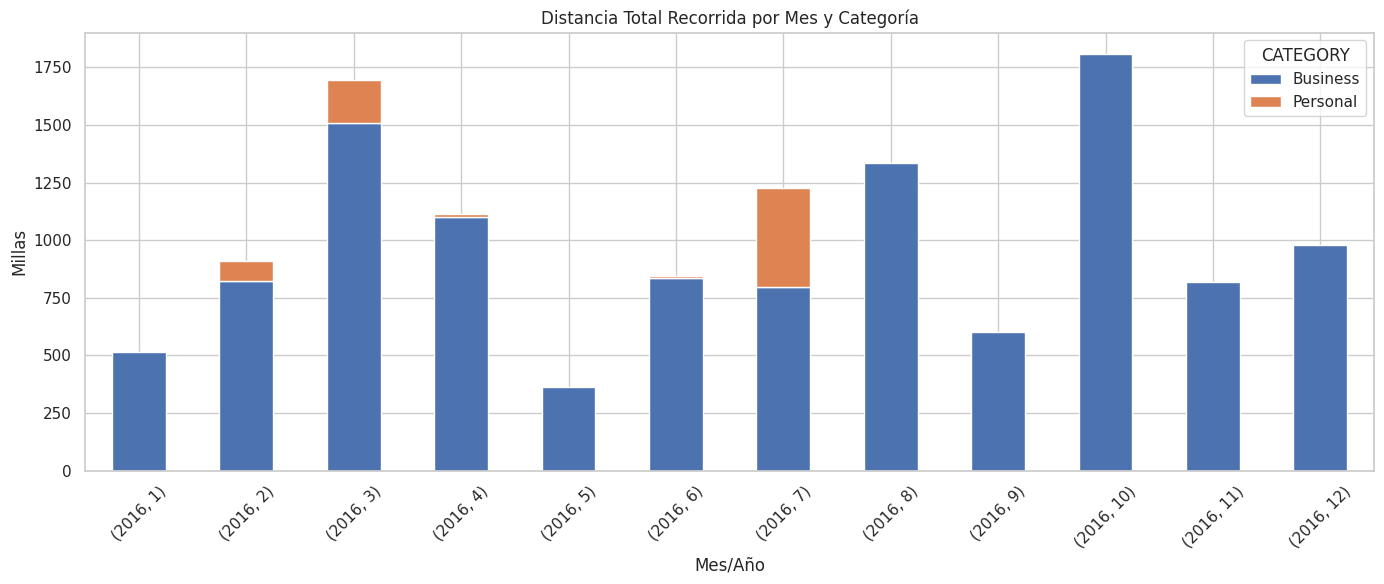

In [39]:
# -------------------------------
# 1. Análisis de distancia mensual por categoría
# -------------------------------
monthly_distance = df.groupby(['YEAR', 'MONTH', 'CATEGORY'])['MILES'].sum().unstack()
monthly_distance.plot(kind='bar', stacked=True, figsize=(14, 6))
plt.title('Distancia Total Recorrida por Mes y Categoría')
plt.ylabel('Millas')
plt.xlabel('Mes/Año')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

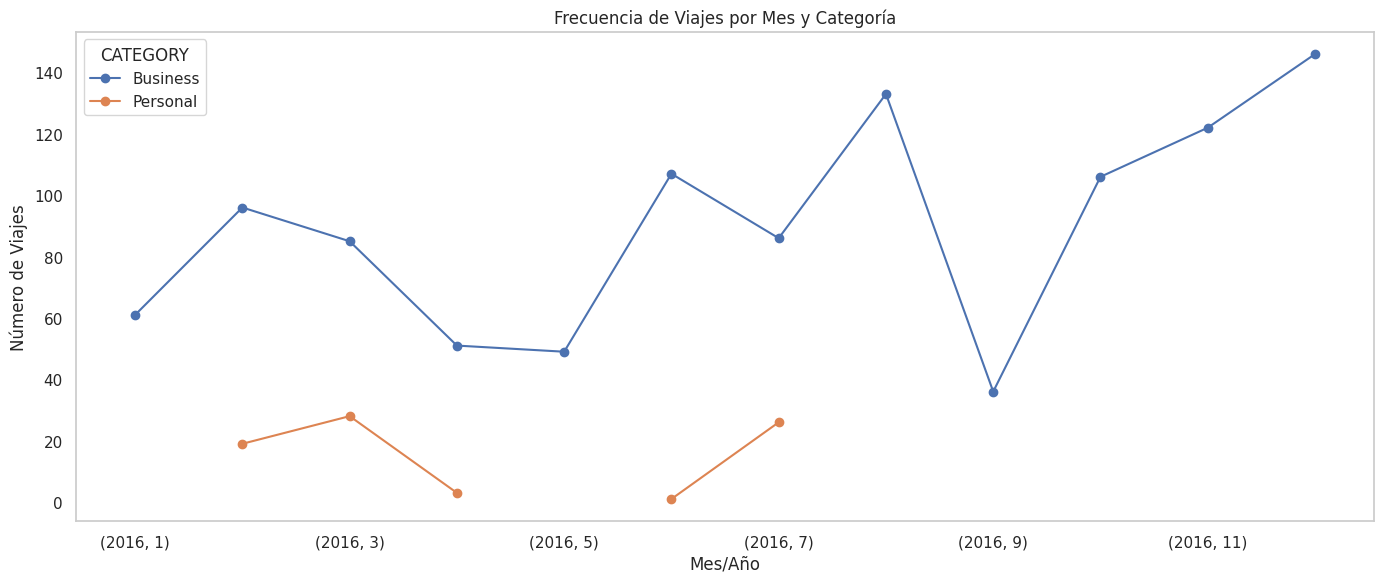

In [40]:
# -------------------------------
# 2. Frecuencia de viajes mensual por categoría
# -------------------------------
monthly_trips = data.groupby(['YEAR', 'MONTH', 'CATEGORY']).size().unstack()
monthly_trips.plot(kind='line', figsize=(14, 6), marker='o')
plt.title('Frecuencia de Viajes por Mes y Categoría')
plt.ylabel('Número de Viajes')
plt.xlabel('Mes/Año')
plt.grid()
plt.tight_layout()
plt.show()

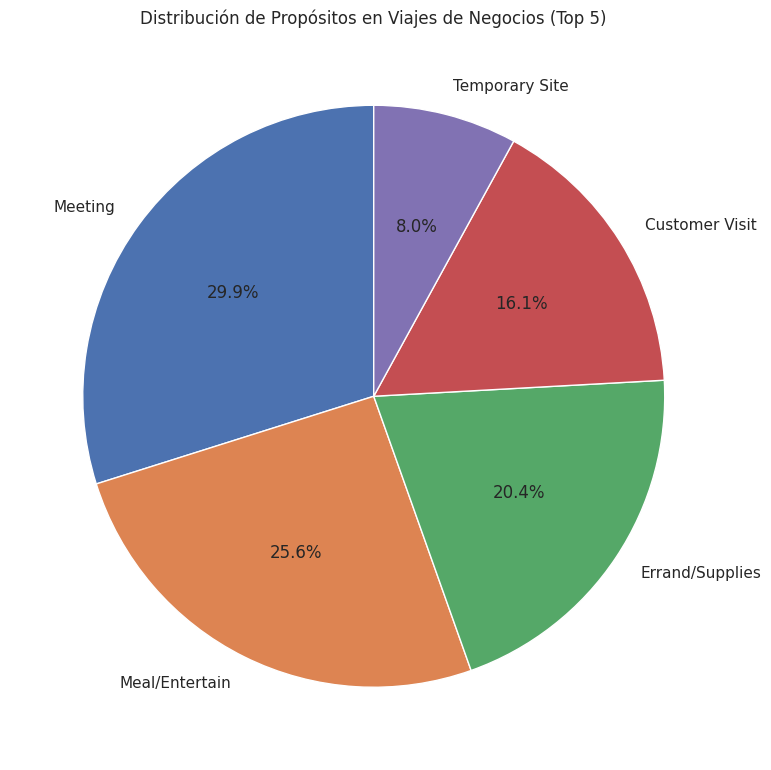

In [41]:
# -------------------------------
# 3. Propósitos más comunes en viajes de negocios (top 5)
# -------------------------------
if 'PURPOSE' in data.columns:
    business_data = data[data['CATEGORY'] == 'Business']
    top_purposes = business_data['PURPOSE'].value_counts().head(5)
    top_purposes.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), startangle=90)
    plt.title('Distribución de Propósitos en Viajes de Negocios (Top 5)')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


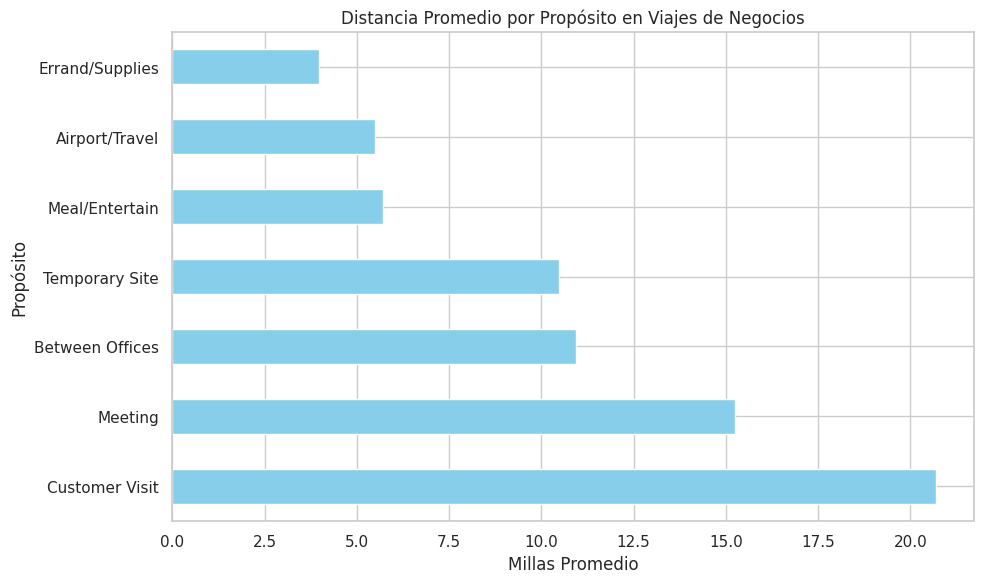

In [42]:
# -------------------------------
# 4. Correlación entre propósito y distancia en viajes de negocios
# -------------------------------
if 'PURPOSE' in data.columns:
    purpose_distance = business_data.groupby('PURPOSE')['MILES'].mean().sort_values(ascending=False).head(10)
    purpose_distance.plot(kind='barh', figsize=(10, 6), color='skyblue')
    plt.title('Distancia Promedio por Propósito en Viajes de Negocios')
    plt.xlabel('Millas Promedio')
    plt.ylabel('Propósito')
    plt.tight_layout()
    plt.show()